In [2]:
import mido 
from mido import MidiFile
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 

In [3]:
# Open the MIDI file
mid = MidiFile(Path('midi files', 'mix.mid'))
#key is metadata? there's a simple function for it
#return key and notes (transposed to c major) per quarter note as an array

# Initialize time accumulator
absolute_time = 0

# Iterate through tracks and messages
for track in mid.tracks:
    absolute_time = 0
    for msg in track:
        # Accumulate delta time to get absolute time
        absolute_time += msg.time
        
        # Check for note messages
        if msg.type == 'note_on' and msg.velocity > 0:
            print(f'Note On: {msg.note} at time: {absolute_time}')
        elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
            print(f'Note Off: {msg.note} at time: {absolute_time}')

Note On: 78 at time: 0
Note On: 76 at time: 239
Note Off: 78 at time: 239
Note On: 74 at time: 465
Note Off: 76 at time: 465
Note Off: 74 at time: 945
Note On: 76 at time: 974
Note Off: 76 at time: 1440
Note On: 78 at time: 1440
Note On: 76 at time: 1913
Note Off: 78 at time: 1913
Note Off: 76 at time: 2393
Note On: 78 at time: 2409
Note On: 76 at time: 2627
Note Off: 78 at time: 2627
Note Off: 76 at time: 2867
Note On: 74 at time: 2881
Note Off: 74 at time: 3835
Note On: 76 at time: 3835
Note Off: 76 at time: 4304
Note On: 78 at time: 4304
Note Off: 78 at time: 7180
Note On: 79 at time: 7180
Note Off: 79 at time: 7660
Note On: 78 at time: 7680
Note Off: 78 at time: 8640
Note On: 79 at time: 8653
Note On: 76 at time: 9127
Note Off: 79 at time: 9127
Note Off: 76 at time: 9594
Note On: 79 at time: 9594
Note Off: 79 at time: 10074
Note On: 78 at time: 10095
Note On: 76 at time: 11038
Note Off: 78 at time: 11038
Note Off: 76 at time: 11518
Note On: 78 at time: 11534
Note Off: 78 at time: 1

In [4]:
test = mid.tracks
len(test)

5

In [5]:
test[0]

MidiTrack([
  MetaMessage('set_tempo', tempo=530972, time=0),
  MetaMessage('time_signature', numerator=4, denominator=4, clocks_per_click=24, notated_32nd_notes_per_beat=8, time=0),
  MetaMessage('end_of_track', time=1)])

In [6]:
test[1]

MidiTrack([
  Message('program_change', channel=0, program=40, time=0),
  Message('note_on', channel=0, note=78, velocity=64, time=0),
  Message('note_on', channel=0, note=76, velocity=64, time=239),
  Message('note_on', channel=0, note=78, velocity=0, time=0),
  Message('note_on', channel=0, note=74, velocity=64, time=226),
  Message('note_on', channel=0, note=76, velocity=0, time=0),
  Message('note_on', channel=0, note=74, velocity=0, time=480),
  Message('note_on', channel=0, note=76, velocity=64, time=29),
  Message('note_on', channel=0, note=76, velocity=0, time=466),
  Message('note_on', channel=0, note=78, velocity=64, time=0),
  Message('note_on', channel=0, note=76, velocity=64, time=473),
  Message('note_on', channel=0, note=78, velocity=0, time=0),
  Message('note_on', channel=0, note=76, velocity=0, time=480),
  Message('note_on', channel=0, note=78, velocity=64, time=16),
  Message('note_on', channel=0, note=76, velocity=64, time=218),
  Message('note_on', channel=0, note

In [7]:
test[2]

MidiTrack([
  Message('program_change', channel=1, program=40, time=0),
  Message('note_on', channel=1, note=69, velocity=64, time=0),
  Message('note_on', channel=1, note=69, velocity=0, time=479),
  Message('note_on', channel=1, note=71, velocity=64, time=15),
  Message('note_on', channel=1, note=69, velocity=64, time=456),
  Message('note_on', channel=1, note=71, velocity=0, time=0),
  Message('note_on', channel=1, note=69, velocity=0, time=960),
  Message('note_on', channel=1, note=71, velocity=64, time=48),
  Message('note_on', channel=1, note=66, velocity=64, time=464),
  Message('note_on', channel=1, note=71, velocity=0, time=0),
  Message('note_on', channel=1, note=66, velocity=0, time=953),
  Message('note_on', channel=1, note=71, velocity=64, time=0),
  Message('note_on', channel=1, note=69, velocity=64, time=450),
  Message('note_on', channel=1, note=71, velocity=0, time=0),
  Message('note_on', channel=1, note=69, velocity=0, time=4320),
  Message('note_on', channel=1, note

In [8]:
mid.ticks_per_beat

480

In [45]:
def get_piano_roll(midi_filename):
    """ 
    arguments: path to a midi file
    returns: four matrices S, A, T, B of dimension (num_pitches) x (num quarter notes) containing note info for each part
    #also return a vector for each of base chord (e.g. B not B7) over time
    """

    #load in the file
    mid = MidiFile(Path('midi files', midi_filename+'.mid'))

    #get parameters
    meta_track = mid.tracks[0] #grab the track that stores the metadata
    for msg in meta_track:
        #grab the tempo
        if msg.type == 'set_tempo': 
            tempo = msg.tempo
        # elif msg.type == 'time_signature':
        #     numerator = msg.numerator
        #     denominator = msg.denominator

        #is there anything else we want from this?        

    PPQ = mid.ticks_per_beat #get PPQ (samples per quarter note)

    length_sec = mid.length #length of the track in seconds
    
    length_ticks = mido.second2tick(length_sec, PPQ, tempo) #turns the length of the file in seconds to the length of the file in ticks?

    #calculate the number of beats
    num_beats = int(length_ticks / PPQ)
    #num_32nd_notes = 8 * num_beats
    num_32nd_notes = num_beats #placeholder so I don't have to rename variables

    #initialize output matrices
    S = np.zeros((128, num_beats))
    A = np.zeros((128, num_beats))
    T = np.zeros((128, num_beats))
    B = np.zeros((128, num_beats))

    list_of_parts = [S, A, T, B]

    active_notes = np.zeros(128)
    
    #load in each part
    for i in range(1, len(mid.tracks)): #loop over all non-metadata tracks
        track = mid.tracks[i] #index into the right part of the midi file (one indexed)
        output_array = list_of_parts[i-1] #which part are we outputing to (zero indexed)
        num_32nd_note = 0 #variable to track which beat we're in
        absolute_time = 0 #reset absolute time per track

        for msg in track:
            # Accumulate delta time to get absolute time (midi files store time relatively)
            absolute_time += msg.time

            # Check for note messages
            if msg.type == 'note_on' and msg.velocity > 0:
                note = msg.note
                active_notes[note] = 1
            elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
                note = msg.note
                active_notes[note] = 0

            # save active notes to output array
            # note that depending on what frequency we want to look 
            if absolute_time / (PPQ/8) > num_32nd_note:
                #how many 32nd notes have I passed? How many columns of output do I need to update
                num_passed_notes = int(absolute_time // (PPQ/8) - num_32nd_note)
                new_num_32nd_note = num_32nd_note + num_passed_notes

                #actually update the array
                output_array[:, num_32nd_note:new_num_32nd_note] = np.tile(active_notes, (num_passed_notes, 1)).T
                num_32nd_note = new_num_32nd_note

                # output_array[:, num_32nd_note:num_32nd_note+num_passed_notes] = np.tile(active_notes, (num_passed_notes, 1)).T

                if num_32nd_note == num_32nd_notes: #we're done looping through the track
                    break

    return (S, A, T, B)

In [44]:
S, A, T, B = get_piano_roll('mix')

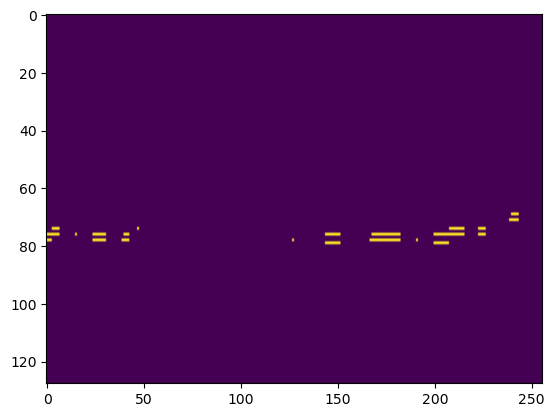

(array([], dtype=int64),)


In [43]:
plt.imshow(S, aspect='auto')
plt.show()
print(np.nonzero(B[:, 16]))

In [12]:
PPQ = mid.ticks_per_beat

length_sec = mid.length #length of the track in seconds

meta_track = mid.tracks[0] #grab the track that stores the metadata
for msg in meta_track:
    #grab the tempo
    if msg.type == 'set_tempo': 
        tempo = msg.tempo

length_ticks = mido.second2tick(length_sec, PPQ, tempo)
print(length_ticks)

15383


In [13]:
num_beats = length_ticks / PPQ
print(num_beats)

32.047916666666666


In [14]:
print(num_beats / (length_sec * 1/60))

113.0003088675109


In [15]:
print(length_sec)

17.016546408333333


In [ ]:
a = np.array([1,2,3,4,5])
print(np.tile(a, (2, 1)))

[[1 2 3 4 5 1 2 3 4 5]]
